# Avance 2 — Modelo relacional de ventas

## Objetivo

Construir un modelo relacional a partir del dataset limpio generado en el Avance 1.

El modelo estará compuesto por las siguientes tablas:

- Facturas
- DetalleFacturas
- Productos
- Clientes
- Sucursales
- Ciudades
- Vendedores

También se definirán las claves primarias y foráneas, se validará la integridad referencial y se exportarán las tablas a un archivo Excel para utilizarlas posteriormente en Power BI.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path("../Avance_1/ventasTransformed.csv")

ventas_df = pd.read_csv(data_path)

print(f"Filas: {ventas_df.shape[0]:,}")
print(f"Columnas: {ventas_df.shape[1]}")
print("\nNombres de las columnas:")
print(ventas_df.columns.tolist())

Filas: 30,000
Columnas: 33

Nombres de las columnas:
['VentaID', 'FechaVenta', 'HoraVenta', 'SucursalNombre', 'CiudadSucursal', 'VendedorNombre', 'ClienteNombre', 'GeneroCliente', 'EdadCliente', 'EmailCliente', 'TelefonoCliente', 'DireccionCliente', 'MetodoPago', 'NombreProducto1', 'MarcaProducto1', 'CantidadProducto1', 'PrecioUnitarioProducto1', 'SubtotalProducto1', 'NombreProducto2', 'MarcaProducto2', 'CantidadProducto2', 'PrecioUnitarioProducto2', 'SubtotalProducto2', 'NombreProducto3', 'MarcaProducto3', 'CantidadProducto3', 'PrecioUnitarioProducto3', 'SubtotalProducto3', 'DescuentoVenta', 'TotalVenta', 'AnioVenta', 'MesNumero', 'MesNombre']


In [3]:
for position, column in enumerate(ventas_df.columns, start=1):
    print(f"{position:02}. {column}")

01. VentaID
02. FechaVenta
03. HoraVenta
04. SucursalNombre
05. CiudadSucursal
06. VendedorNombre
07. ClienteNombre
08. GeneroCliente
09. EdadCliente
10. EmailCliente
11. TelefonoCliente
12. DireccionCliente
13. MetodoPago
14. NombreProducto1
15. MarcaProducto1
16. CantidadProducto1
17. PrecioUnitarioProducto1
18. SubtotalProducto1
19. NombreProducto2
20. MarcaProducto2
21. CantidadProducto2
22. PrecioUnitarioProducto2
23. SubtotalProducto2
24. NombreProducto3
25. MarcaProducto3
26. CantidadProducto3
27. PrecioUnitarioProducto3
28. SubtotalProducto3
29. DescuentoVenta
30. TotalVenta
31. AnioVenta
32. MesNumero
33. MesNombre


In [4]:
for position in range(23, 30):
    print(f"{position + 1:02}. {ventas_df.columns[position]}")

24. NombreProducto3
25. MarcaProducto3
26. CantidadProducto3
27. PrecioUnitarioProducto3
28. SubtotalProducto3
29. DescuentoVenta
30. TotalVenta


## 1. Exploración y validación del dataset

Antes de construir el modelo relacional se revisan los tipos de datos, valores nulos, duplicados y campos disponibles. Esta validación permite asegurar que las tablas resultantes se creen a partir de datos consistentes.

In [5]:
data_quality = pd.DataFrame({
    "DataType": ventas_df.dtypes.astype(str),
    "NullCount": ventas_df.isna().sum(),
    "NullPercentage": (ventas_df.isna().mean() * 100).round(2),
    "UniqueValues": ventas_df.nunique()
})

data_quality

,DataType,NullCount,NullPercentage,UniqueValues
VentaID,int64,0,0.00,30000
FechaVenta,str,0,0.00,4017
HoraVenta,str,0,0.00,25369
SucursalNombre,str,0,0.00,6
CiudadSucursal,str,0,0.00,5
VendedorNombre,str,0,0.00,30
ClienteNombre,str,0,0.00,17449
GeneroCliente,str,0,0.00,2
EdadCliente,int64,0,0.00,34
EmailCliente,str,0,0.00,15725


In [6]:
columns_with_nulls = data_quality[data_quality["NullCount"] > 0]

print("Columnas con valores nulos:")
if columns_with_nulls.empty:
    print("No se encontraron valores nulos.")
else:
    display(columns_with_nulls)

print(f"\nFilas duplicadas completas: {ventas_df.duplicated().sum():,}")
print(f"VentaID duplicados: {ventas_df['VentaID'].duplicated().sum():,}")

Columnas con valores nulos:


,DataType,NullCount,NullPercentage,UniqueValues
NombreProducto2,str,9988,33.29,40
MarcaProducto2,str,9988,33.29,10
CantidadProducto2,float64,9988,33.29,2
PrecioUnitarioProducto2,float64,9988,33.29,21
SubtotalProducto2,float64,9988,33.29,34
NombreProducto3,str,19953,66.51,40
MarcaProducto3,str,19953,66.51,10
CantidadProducto3,float64,19953,66.51,2
PrecioUnitarioProducto3,float64,19953,66.51,21
SubtotalProducto3,float64,19953,66.51,34



Filas duplicadas completas: 0
VentaID duplicados: 0


## 2. Diseño del modelo relacional

El dataset original contiene información de distintas entidades dentro de una sola tabla. Para reducir redundancia y facilitar el análisis, los datos se separarán en siete tablas relacionadas:

- **Facturas:** información general de cada venta.
- **DetalleFacturas:** productos incluidos en cada factura.
- **Productos:** catálogo único de productos.
- **Clientes:** información única de los clientes.
- **Sucursales:** catálogo de sucursales.
- **Ciudades:** ciudades donde operan las sucursales.
- **Vendedores:** información única de los vendedores.

Los campos de Producto 1, Producto 2 y Producto 3 se transformarán de columnas a filas para que cada registro de `DetalleFacturas` represente un producto vendido dentro de una factura.

In [7]:
detail_parts = []

for product_number in range(1, 4):
    product_detail = ventas_df[
        [
            "VentaID",
            f"NombreProducto{product_number}",
            f"MarcaProducto{product_number}",
            f"CantidadProducto{product_number}",
            f"PrecioUnitarioProducto{product_number}",
            f"SubtotalProducto{product_number}"
        ]
    ].copy()

    product_detail.columns = [
        "FacturaID",
        "NombreProducto",
        "Marca",
        "Cantidad",
        "PrecioUnitario",
        "Subtotal"
    ]

    product_detail["LineaProducto"] = product_number
    product_detail = product_detail.dropna(subset=["NombreProducto"])

    detail_parts.append(product_detail)

detalle_base = pd.concat(detail_parts, ignore_index=True)

print(f"Filas del dataset original: {len(ventas_df):,}")
print(f"Productos vendidos registrados: {len(detalle_base):,}")

detalle_base.head(10)

Filas del dataset original: 30,000
Productos vendidos registrados: 60,059


,FacturaID,NombreProducto,Marca,Cantidad,PrecioUnitario,Subtotal,LineaProducto
0,1,Apple MacBook Pro 16,Apple,1.0,9600000.0,9600000.0,1
1,2,Acer Nitro 5,Acer,1.0,4000000.0,4000000.0,1
2,3,Dell Latitude 7420,Dell,2.0,5600000.0,11200000.0,1
3,4,Asus TUF Gaming A15,Asus,1.0,4800000.0,4800000.0,1
4,5,HP Spectre x360,HP,1.0,5200000.0,5200000.0,1
5,6,Samsung Galaxy Book Odyssey,Samsung,1.0,6800000.0,6800000.0,1
6,7,Lenovo IdeaPad 5,Lenovo,2.0,2800000.0,5600000.0,1
7,8,Asus TUF Gaming A15,Asus,2.0,4800000.0,9600000.0,1
8,9,Dell XPS 13,Dell,1.0,4800000.0,4800000.0,1
9,10,Lenovo Legion 5 Pro,Lenovo,2.0,7200000.0,14400000.0,1


In [8]:
price_validation = (
    detalle_base
    .groupby(["NombreProducto", "Marca"])["PrecioUnitario"]
    .nunique()
    .reset_index(name="CantidadPrecios")
)

products_with_multiple_prices = price_validation[
    price_validation["CantidadPrecios"] > 1
]

print(
    "Productos con más de un precio:",
    len(products_with_multiple_prices)
)

products_with_multiple_prices

Productos con más de un precio: 0


,NombreProducto,Marca,CantidadPrecios


In [9]:
productos = (
    detalle_base[
        ["NombreProducto", "Marca", "PrecioUnitario"]
    ]
    .drop_duplicates()
    .sort_values(["Marca", "NombreProducto"])
    .reset_index(drop=True)
    .rename(columns={
        "NombreProducto": "Nombre",
        "PrecioUnitario": "Precio"
    })
)

productos.insert(
    0,
    "ProductoID",
    range(1, len(productos) + 1)
)

print(f"Productos únicos: {len(productos):,}")
productos

Productos únicos: 40


,ProductoID,Nombre,Marca,Precio
0,1,Acer Aspire 5,Acer,2000000.0
1,2,Acer Nitro 5,Acer,4000000.0
2,3,Acer Predator Helios 300,Acer,5600000.0
3,4,Acer Swift 3,Acer,2600000.0
4,5,Apple MacBook Air M1,Apple,5500000.0
5,6,Apple MacBook Pro 14,Apple,8000000.0
6,7,Apple MacBook Pro 16,Apple,9600000.0
7,8,Apple iMac 24,Apple,6400000.0
8,9,Asus ROG Strix G15,Asus,6400000.0
9,10,Asus TUF Gaming A15,Asus,4800000.0


In [10]:
detalle_facturas = detalle_base.merge(
    productos,
    left_on=["NombreProducto", "Marca", "PrecioUnitario"],
    right_on=["Nombre", "Marca", "Precio"],
    how="left",
    validate="many_to_one"
)

detalle_facturas = detalle_facturas[
    [
        "FacturaID",
        "ProductoID",
        "LineaProducto",
        "Cantidad",
        "PrecioUnitario",
        "Subtotal"
    ]
].copy()

detalle_facturas["Cantidad"] = (
    detalle_facturas["Cantidad"].astype(int)
)

detalle_facturas.insert(
    0,
    "DetalleID",
    range(1, len(detalle_facturas) + 1)
)

print(f"Registros en DetalleFacturas: {len(detalle_facturas):,}")
print(
    "ProductoID sin correspondencia:",
    detalle_facturas["ProductoID"].isna().sum()
)

detalle_facturas.head(10)

Registros en DetalleFacturas: 60,059
ProductoID sin correspondencia: 0


,DetalleID,FacturaID,ProductoID,LineaProducto,Cantidad,PrecioUnitario,Subtotal
0,1,1,7,1,1,9600000.0,9600000.0
1,2,2,2,1,1,4000000.0,4000000.0
2,3,3,15,1,2,5600000.0,11200000.0
3,4,4,10,1,1,4800000.0,4800000.0
4,5,5,20,1,1,5200000.0,5200000.0
5,6,6,38,1,1,6800000.0,6800000.0
6,7,7,21,1,2,2800000.0,5600000.0
7,8,8,10,1,2,4800000.0,9600000.0
8,9,9,16,1,1,4800000.0,4800000.0
9,10,10,22,1,2,7200000.0,14400000.0


In [11]:
client_columns = [
    "ClienteNombre",
    "GeneroCliente",
    "EdadCliente",
    "EmailCliente",
    "TelefonoCliente",
    "DireccionCliente"
]

clientes = (
    ventas_df[client_columns]
    .drop_duplicates()
    .sort_values(["ClienteNombre", "EmailCliente"])
    .reset_index(drop=True)
    .rename(columns={
        "ClienteNombre": "Nombre",
        "GeneroCliente": "Genero",
        "EdadCliente": "Edad",
        "EmailCliente": "Email",
        "TelefonoCliente": "Telefono",
        "DireccionCliente": "Direccion"
    })
)

clientes.insert(
    0,
    "ClienteID",
    range(1, len(clientes) + 1)
)

print(f"Clientes únicos: {len(clientes):,}")
clientes.head(10)

Clientes únicos: 17,453


,ClienteID,Nombre,Genero,Edad,Email,Telefono,Direccion
0,1,Aarón Aguilera-Esteban,M,39,aaron78@yahoo.com,+34806 28 91 01,cra 75 #43-69
1,2,Aarón Asenjo Reguera,M,30,aaron13@gmail.com,+34714 538 644,cll 16 #89-59
2,3,Aarón Asensio Martín,M,34,aaron14@yahoo.com,+34886 38 77 52,cll 93 #99-72
3,4,Aarón Blazquez Fabregat,M,46,aaron6@gmail.com,+34 888911631,cra 2 #45-67
4,5,Aarón Cabrera Pedraza,M,34,aaron36@yahoo.com,+34 878 04 20 66,cll 36 #8-20
5,6,Aarón Fajardo,M,26,No disponible,+34 978672548,cra 68 #65-55
6,7,Aarón Gibert Araujo,M,45,aaron90@yahoo.com,+34878541216,cll 59 #8-24
7,8,Aarón Herrera Tello,M,37,aaron11@hotmail.com,+34 826 474 028,cll 2 #72-64
8,9,Aarón Ibarra-Blázquez,M,33,aaron71@gmail.com,+34 971 719 532,cra 28 #97-76
9,10,Aarón Jáuregui Pozo,M,32,aaron82@gmail.com,+34920159927,cra 16 #60-30


In [12]:
branch_city_validation = (
    ventas_df
    .groupby("SucursalNombre")["CiudadSucursal"]
    .agg(
        CantidadCiudades="nunique",
        Ciudades=lambda values: sorted(values.unique())
    )
    .reset_index()
)

branch_city_validation

,SucursalNombre,CantidadCiudades,Ciudades
0,TechCore Bogotá #1,2,"[Bogotá, No especificado]"
1,TechCore Bogotá #2,2,"[Bogotá, No especificado]"
2,TechCore Cali,2,"[Cali, No especificado]"
3,TechCore Medellín #1,2,"[Medellín, No especificado]"
4,TechCore Medellín #2,2,"[Medellín, No especificado]"
5,TechCore Pereira,2,"[No especificado, Pereira]"


In [13]:
branch_city_map = {
    "TechCore Bogotá #1": "Bogotá",
    "TechCore Bogotá #2": "Bogotá",
    "TechCore Cali": "Cali",
    "TechCore Medellín #1": "Medellín",
    "TechCore Medellín #2": "Medellín",
    "TechCore Pereira": "Pereira"
}

ventas_df["CiudadSucursal"] = (
    ventas_df["SucursalNombre"].map(branch_city_map)
)

branch_city_check = (
    ventas_df
    .groupby("SucursalNombre")["CiudadSucursal"]
    .agg(
        CantidadCiudades="nunique",
        Ciudades=lambda values: sorted(values.unique())
    )
    .reset_index()
)

branch_city_check

,SucursalNombre,CantidadCiudades,Ciudades
0,TechCore Bogotá #1,1,[Bogotá]
1,TechCore Bogotá #2,1,[Bogotá]
2,TechCore Cali,1,[Cali]
3,TechCore Medellín #1,1,[Medellín]
4,TechCore Medellín #2,1,[Medellín]
5,TechCore Pereira,1,[Pereira]


In [14]:
ciudades = (
    ventas_df[["CiudadSucursal"]]
    .drop_duplicates()
    .sort_values("CiudadSucursal")
    .reset_index(drop=True)
    .rename(columns={"CiudadSucursal": "NombreCiudad"})
)

ciudades.insert(
    0,
    "CiudadID",
    range(1, len(ciudades) + 1)
)

sucursales = (
    ventas_df[
        ["SucursalNombre", "CiudadSucursal"]
    ]
    .drop_duplicates()
    .merge(
        ciudades,
        left_on="CiudadSucursal",
        right_on="NombreCiudad",
        how="left",
        validate="many_to_one"
    )
    [["SucursalNombre", "CiudadID"]]
    .rename(columns={"SucursalNombre": "Nombre"})
    .sort_values("Nombre")
    .reset_index(drop=True)
)

sucursales.insert(
    0,
    "SucursalID",
    range(1, len(sucursales) + 1)
)

print(f"Ciudades: {len(ciudades)}")
display(ciudades)

print(f"Sucursales: {len(sucursales)}")
display(sucursales)

Ciudades: 4


,CiudadID,NombreCiudad
0,1,Bogotá
1,2,Cali
2,3,Medellín
3,4,Pereira


Sucursales: 6


,SucursalID,Nombre,CiudadID
0,1,TechCore Bogotá #1,1
1,2,TechCore Bogotá #2,1
2,3,TechCore Cali,2
3,4,TechCore Medellín #1,3
4,5,TechCore Medellín #2,3
5,6,TechCore Pereira,4


In [15]:
vendedores = (
    ventas_df[["VendedorNombre"]]
    .drop_duplicates()
    .sort_values("VendedorNombre")
    .reset_index(drop=True)
    .rename(columns={"VendedorNombre": "Nombre"})
)

vendedores.insert(
    0,
    "VendedorID",
    range(1, len(vendedores) + 1)
)

print(f"Vendedores únicos: {len(vendedores)}")
vendedores

Vendedores únicos: 30


,VendedorID,Nombre
0,1,Almudena Adelaida Lledó Garrido
1,2,Amílcar Ortega-Alberto
2,3,Ana Sofía Llopis Blázquez
3,4,Anacleto Morera Segovia
4,5,Armida Azorin Plaza
5,6,Aura del Bermúdez
6,7,Basilio Marcos Barrena
7,8,Carina Parejo Carranza
8,9,Claudia Sastre-Quintero
9,10,Clímaco Salinas Zabaleta


In [16]:
client_lookup = clientes.rename(columns={
    "Nombre": "ClienteNombre",
    "Genero": "GeneroCliente",
    "Edad": "EdadCliente",
    "Email": "EmailCliente",
    "Telefono": "TelefonoCliente",
    "Direccion": "DireccionCliente"
})[client_columns + ["ClienteID"]]

branch_lookup = sucursales.rename(
    columns={"Nombre": "SucursalNombre"}
)[["SucursalNombre", "SucursalID"]]

seller_lookup = vendedores.rename(
    columns={"Nombre": "VendedorNombre"}
)[["VendedorNombre", "VendedorID"]]

invoice_columns = [
    "VentaID",
    "FechaVenta",
    "HoraVenta",
    "MetodoPago",
    "DescuentoVenta",
    "TotalVenta",
    "AnioVenta",
    "MesNumero",
    "MesNombre",
    "SucursalNombre",
    "VendedorNombre"
] + client_columns

facturas = ventas_df[invoice_columns].copy()

facturas = facturas.merge(
    client_lookup,
    on=client_columns,
    how="left",
    validate="many_to_one"
)

facturas = facturas.merge(
    branch_lookup,
    on="SucursalNombre",
    how="left",
    validate="many_to_one"
)

facturas = facturas.merge(
    seller_lookup,
    on="VendedorNombre",
    how="left",
    validate="many_to_one"
)

facturas = facturas.rename(columns={
    "VentaID": "FacturaID",
    "FechaVenta": "Fecha",
    "HoraVenta": "Hora",
    "DescuentoVenta": "Descuento"
})

facturas = facturas[
    [
        "FacturaID",
        "Fecha",
        "Hora",
        "SucursalID",
        "ClienteID",
        "VendedorID",
        "MetodoPago",
        "Descuento",
        "TotalVenta",
        "AnioVenta",
        "MesNumero",
        "MesNombre"
    ]
].copy()

facturas["Fecha"] = pd.to_datetime(
    facturas["Fecha"],
    errors="raise"
)

print(f"Facturas creadas: {len(facturas):,}")
print(
    "Claves foráneas sin correspondencia:",
    facturas[
        ["SucursalID", "ClienteID", "VendedorID"]
    ].isna().sum().sum()
)

facturas.head(10)

Facturas creadas: 30,000
Claves foráneas sin correspondencia: 0


,FacturaID,Fecha,Hora,SucursalID,ClienteID,VendedorID,MetodoPago,Descuento,TotalVenta,AnioVenta,MesNumero,MesNombre
0,1,2015-12-31,05:42:43,6,2522,2,Tarjeta Crédito,0.00,31200000.0,2015,12,December
1,2,2019-03-23,19:03:21,4,16168,3,Billetera Digital,0.00,10800000.0,2019,3,March
2,3,2018-12-23,02:32:34,5,7064,22,Tarjeta Débito,0.00,21900000.0,2018,12,December
3,4,2015-11-14,00:37:36,5,12295,22,Billetera Digital,0.00,13600000.0,2015,11,November
4,5,2016-11-29,10:34:20,3,17094,20,Tarjeta Crédito,0.00,13900000.0,2016,11,November
5,6,2015-01-08,22:33:55,3,3825,10,Billetera Digital,0.00,17600000.0,2015,1,January
6,7,2022-10-02,11:56:06,3,8127,20,Billetera Digital,0.15,12920000.0,2022,10,October
7,8,2022-06-04,07:00:48,6,3979,8,Tarjeta Crédito,0.05,23940000.0,2022,6,June
8,9,2019-01-14,12:27:53,2,6970,12,Tarjeta Crédito,0.00,4800000.0,2019,1,January
9,10,2023-07-19,14:25:30,2,15556,5,Transferencia,0.00,28000000.0,2023,7,July


## 3. Validación de claves e integridad referencial

Se verifica que cada clave primaria sea única y no contenga valores nulos. También se comprueba que todas las claves foráneas existan en sus respectivas tablas de referencia.

In [17]:
primary_keys = {
    "Facturas": (facturas, "FacturaID"),
    "DetalleFacturas": (detalle_facturas, "DetalleID"),
    "Productos": (productos, "ProductoID"),
    "Clientes": (clientes, "ClienteID"),
    "Sucursales": (sucursales, "SucursalID"),
    "Ciudades": (ciudades, "CiudadID"),
    "Vendedores": (vendedores, "VendedorID")
}

primary_key_results = []

for table_name, (table, primary_key) in primary_keys.items():
    primary_key_results.append({
        "Tabla": table_name,
        "ClavePrimaria": primary_key,
        "Filas": len(table),
        "Nulos": table[primary_key].isna().sum(),
        "Duplicados": table[primary_key].duplicated().sum(),
        "Valida": (
            table[primary_key].notna().all()
            and table[primary_key].is_unique
        )
    })

primary_key_validation = pd.DataFrame(primary_key_results)

primary_key_validation

,Tabla,ClavePrimaria,Filas,Nulos,Duplicados,Valida
0,Facturas,FacturaID,30000,0,0,True
1,DetalleFacturas,DetalleID,60059,0,0,True
2,Productos,ProductoID,40,0,0,True
3,Clientes,ClienteID,17453,0,0,True
4,Sucursales,SucursalID,6,0,0,True
5,Ciudades,CiudadID,4,0,0,True
6,Vendedores,VendedorID,30,0,0,True


In [19]:
print(
    primary_key_validation[
        ["Tabla", "Nulos", "Duplicados", "Valida"]
    ].to_string(index=False)
)

          Tabla  Nulos  Duplicados  Valida
       Facturas      0           0    True
DetalleFacturas      0           0    True
      Productos      0           0    True
       Clientes      0           0    True
     Sucursales      0           0    True
       Ciudades      0           0    True
     Vendedores      0           0    True


In [20]:
foreign_key_checks = [
    {
        "Relacion": "DetalleFacturas.FacturaID → Facturas.FacturaID",
        "RegistrosInvalidos": (
            ~detalle_facturas["FacturaID"].isin(facturas["FacturaID"])
        ).sum()
    },
    {
        "Relacion": "DetalleFacturas.ProductoID → Productos.ProductoID",
        "RegistrosInvalidos": (
            ~detalle_facturas["ProductoID"].isin(productos["ProductoID"])
        ).sum()
    },
    {
        "Relacion": "Facturas.ClienteID → Clientes.ClienteID",
        "RegistrosInvalidos": (
            ~facturas["ClienteID"].isin(clientes["ClienteID"])
        ).sum()
    },
    {
        "Relacion": "Facturas.SucursalID → Sucursales.SucursalID",
        "RegistrosInvalidos": (
            ~facturas["SucursalID"].isin(sucursales["SucursalID"])
        ).sum()
    },
    {
        "Relacion": "Facturas.VendedorID → Vendedores.VendedorID",
        "RegistrosInvalidos": (
            ~facturas["VendedorID"].isin(vendedores["VendedorID"])
        ).sum()
    },
    {
        "Relacion": "Sucursales.CiudadID → Ciudades.CiudadID",
        "RegistrosInvalidos": (
            ~sucursales["CiudadID"].isin(ciudades["CiudadID"])
        ).sum()
    }
]

foreign_key_validation = pd.DataFrame(foreign_key_checks)
foreign_key_validation["Valida"] = (
    foreign_key_validation["RegistrosInvalidos"] == 0
)

print(foreign_key_validation.to_string(index=False))

                                         Relacion  RegistrosInvalidos  Valida
   DetalleFacturas.FacturaID → Facturas.FacturaID                   0    True
DetalleFacturas.ProductoID → Productos.ProductoID                   0    True
          Facturas.ClienteID → Clientes.ClienteID                   0    True
      Facturas.SucursalID → Sucursales.SucursalID                   0    True
      Facturas.VendedorID → Vendedores.VendedorID                   0    True
          Sucursales.CiudadID → Ciudades.CiudadID                   0    True


In [21]:
print("Valores de Descuento:")
print(facturas["Descuento"].value_counts().sort_index().to_string())

print("\nResumen de importes:")
print(
    facturas[
        ["Descuento", "TotalVenta"]
    ].describe().to_string()
)

Valores de Descuento:
Descuento
0.00    21028
0.05     4430
0.10     3034
0.15     1508

Resumen de importes:
          Descuento    TotalVenta
count  30000.000000  3.000000e+04
mean       0.025037  1.521639e+07
std        0.043413  8.235931e+06
min        0.000000  1.700000e+06
25%        0.000000  8.640000e+06
50%        0.000000  1.440000e+07
75%        0.050000  2.080000e+07
max        0.150000  4.880000e+07


In [22]:
import numpy as np

subtotal_valid = np.isclose(
    detalle_facturas["Subtotal"],
    detalle_facturas["Cantidad"]
    * detalle_facturas["PrecioUnitario"],
    rtol=0,
    atol=0.01
)

invoice_amounts = (
    detalle_facturas
    .groupby("FacturaID", as_index=False)["Subtotal"]
    .sum()
    .rename(columns={"Subtotal": "SubtotalFactura"})
    .merge(
        facturas[
            ["FacturaID", "Descuento", "TotalVenta"]
        ],
        on="FacturaID",
        how="left",
        validate="one_to_one"
    )
)

invoice_amounts["TotalCalculado"] = (
    invoice_amounts["SubtotalFactura"]
    * (1 - invoice_amounts["Descuento"])
)

invoice_amounts["TotalValido"] = np.isclose(
    invoice_amounts["TotalCalculado"],
    invoice_amounts["TotalVenta"],
    rtol=0,
    atol=0.01
)

print(
    "Líneas con subtotal incorrecto:",
    (~subtotal_valid).sum()
)

print(
    "Facturas con total incorrecto:",
    (~invoice_amounts["TotalValido"]).sum()
)

Líneas con subtotal incorrecto: 0
Facturas con total incorrecto: 0


## 4. Reportes de verificación

Se generan reportes rápidos para comprobar que el modelo permite responder preguntas comerciales. Las ventas netas consideran el descuento aplicado a cada factura.

Los reportes incluidos son:

- Total de ventas netas por marca.
- Diez productos con mayor cantidad de unidades vendidas.

In [23]:
sales_analysis = (
    detalle_facturas
    .merge(
        productos[
            ["ProductoID", "Nombre", "Marca"]
        ],
        on="ProductoID",
        how="left",
        validate="many_to_one"
    )
    .merge(
        facturas[
            ["FacturaID", "Descuento"]
        ],
        on="FacturaID",
        how="left",
        validate="many_to_one"
    )
)

sales_analysis["VentaNeta"] = (
    sales_analysis["Subtotal"]
    * (1 - sales_analysis["Descuento"])
)

ventas_por_marca = (
    sales_analysis
    .groupby("Marca", as_index=False)
    .agg(
        UnidadesVendidas=("Cantidad", "sum"),
        VentasNetas=("VentaNeta", "sum")
    )
    .sort_values(
        "VentasNetas",
        ascending=False
    )
    .reset_index(drop=True)
)

ventas_por_marca["VentasNetas"] = (
    ventas_por_marca["VentasNetas"].round(2)
)

ventas_por_marca

,Marca,UnidadesVendidas,VentasNetas
0,Lenovo,21697,1.149497e+11
1,HP,19877,9.440325e+10
2,Dell,16189,8.460436e+10
3,Apple,10783,7.607139e+10
4,Asus,8097,3.238433e+10
5,Acer,7178,2.145418e+10
6,Samsung,2618,1.245680e+10
7,MSI,1374,8.311020e+09
8,Microsoft,1717,8.017840e+09
9,Razer,482,3.838760e+09


In [24]:
top_10_productos = (
    sales_analysis
    .groupby(
        ["ProductoID", "Nombre", "Marca"],
        as_index=False
    )
    .agg(
        UnidadesVendidas=("Cantidad", "sum"),
        VentasNetas=("VentaNeta", "sum")
    )
    .sort_values(
        ["UnidadesVendidas", "VentasNetas"],
        ascending=[False, False]
    )
    .head(10)
    .reset_index(drop=True)
)

top_10_productos["VentasNetas"] = (
    top_10_productos["VentasNetas"].round(2)
)

top_10_productos

,ProductoID,Nombre,Marca,UnidadesVendidas,VentasNetas
0,20,HP Spectre x360,HP,7726,3.919370e+10
1,22,Lenovo Legion 5 Pro,Lenovo,5861,4.116420e+10
2,23,Lenovo ThinkPad X1 Carbon,Lenovo,5814,3.853458e+10
3,24,Lenovo Yoga 7i,Lenovo,5052,2.170498e+10
4,18,HP Omen 16,HP,5011,2.933220e+10
5,21,Lenovo IdeaPad 5,Lenovo,4970,1.354598e+10
6,16,Dell XPS 13,Dell,4526,2.119896e+10
7,15,Dell Latitude 7420,Dell,4507,2.462880e+10
8,19,HP Pavilion 15,HP,4029,1.376095e+10
9,13,Dell Alienware m15,Dell,3658,2.855200e+10


## 5. Relaciones del modelo

Las tablas se conectan mediante las siguientes relaciones de uno a muchos:

- `Ciudades[CiudadID]` → `Sucursales[CiudadID]`
- `Sucursales[SucursalID]` → `Facturas[SucursalID]`
- `Clientes[ClienteID]` → `Facturas[ClienteID]`
- `Vendedores[VendedorID]` → `Facturas[VendedorID]`
- `Facturas[FacturaID]` → `DetalleFacturas[FacturaID]`
- `Productos[ProductoID]` → `DetalleFacturas[ProductoID]`

En todas las relaciones, la tabla ubicada a la izquierda contiene la clave primaria y representa el lado **uno (1)**. La tabla ubicada a la derecha contiene la clave foránea y representa el lado **muchos (*)**.

Las validaciones realizadas confirmaron que todas las claves primarias son únicas, no contienen valores nulos y todas las claves foráneas tienen correspondencia.

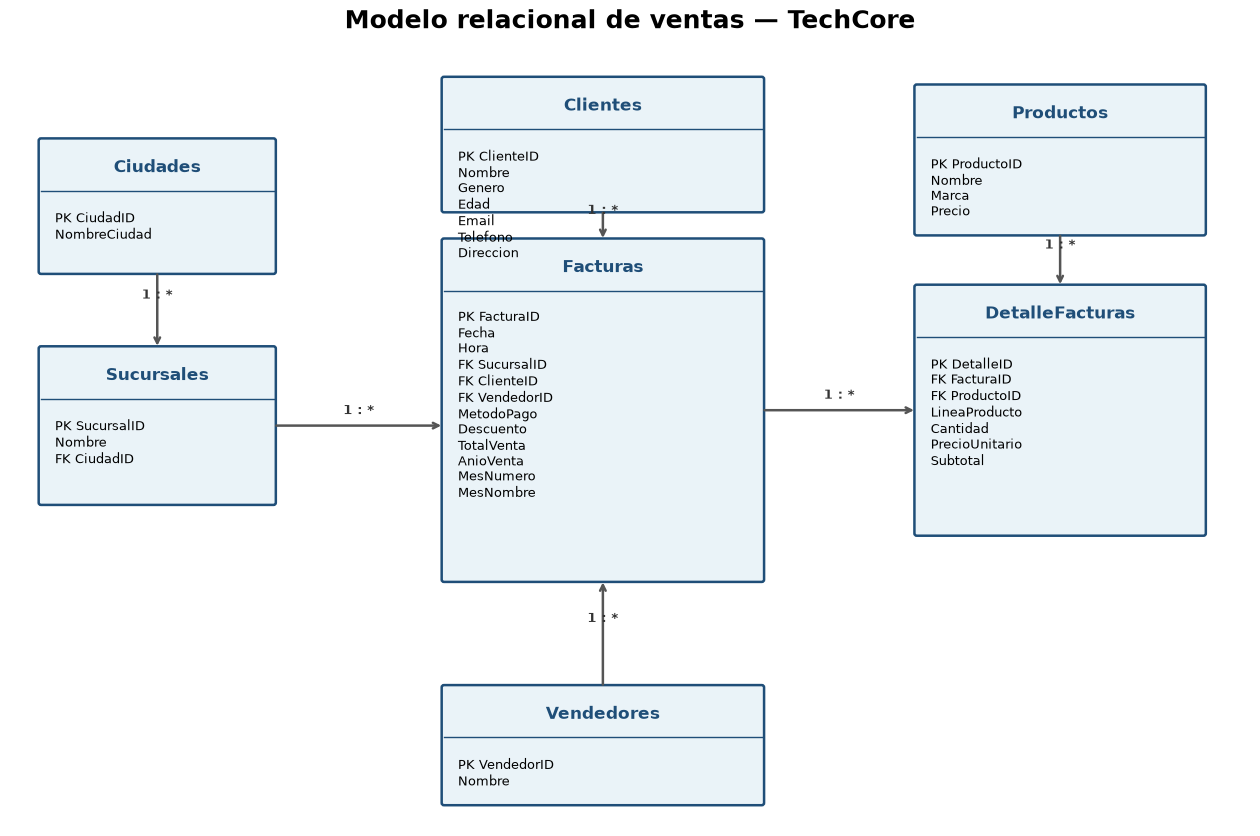

Diagrama guardado en: C:\Users\david\OneDrive\Desktop\Learning\SoyHenry\Projects M3\ProyectoVentas_DavidBucheli\Avance_2\modelo_relacional.png


In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")

def draw_table(x, y, width, height, title, fields):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03",
        linewidth=1.8,
        edgecolor="#1F4E78",
        facecolor="#EAF3F8"
    )
    ax.add_patch(box)

    ax.text(
        x + width / 2,
        y + height - 0.35,
        title,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="#1F4E78"
    )

    ax.plot(
        [x, x + width],
        [y + height - 0.65, y + height - 0.65],
        color="#1F4E78",
        linewidth=1
    )

    ax.text(
        x + 0.18,
        y + height - 0.9,
        "\n".join(fields),
        ha="left",
        va="top",
        fontsize=9
    )

def draw_relation(start, end, label):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={
            "arrowstyle": "->",
            "color": "#555555",
            "linewidth": 1.8
        }
    )

    midpoint = (
        (start[0] + end[0]) / 2,
        (start[1] + end[1]) / 2
    )

    ax.text(
        midpoint[0],
        midpoint[1] + 0.15,
        label,
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="#333333"
    )

draw_table(
    0.4, 7.2, 3.0, 1.7,
    "Ciudades",
    ["PK CiudadID", "NombreCiudad"]
)

draw_table(
    0.4, 4.2, 3.0, 2.0,
    "Sucursales",
    ["PK SucursalID", "Nombre", "FK CiudadID"]
)

draw_table(
    5.6, 3.2, 4.1, 4.4,
    "Facturas",
    [
        "PK FacturaID", "Fecha", "Hora",
        "FK SucursalID", "FK ClienteID",
        "FK VendedorID", "MetodoPago",
        "Descuento", "TotalVenta",
        "AnioVenta", "MesNumero", "MesNombre"
    ]
)

draw_table(
    11.7, 3.8, 3.7, 3.2,
    "DetalleFacturas",
    [
        "PK DetalleID", "FK FacturaID",
        "FK ProductoID", "LineaProducto",
        "Cantidad", "PrecioUnitario", "Subtotal"
    ]
)

draw_table(
    11.7, 7.7, 3.7, 1.9,
    "Productos",
    ["PK ProductoID", "Nombre", "Marca", "Precio"]
)

draw_table(
    5.6, 8.0, 4.1, 1.7,
    "Clientes",
    [
        "PK ClienteID", "Nombre", "Genero",
        "Edad", "Email", "Telefono", "Direccion"
    ]
)

draw_table(
    5.6, 0.3, 4.1, 1.5,
    "Vendedores",
    ["PK VendedorID", "Nombre"]
)

draw_relation((1.9, 7.2), (1.9, 6.2), "1 : *")
draw_relation((3.4, 5.2), (5.6, 5.2), "1 : *")
draw_relation((7.65, 8.0), (7.65, 7.6), "1 : *")
draw_relation((7.65, 1.8), (7.65, 3.2), "1 : *")
draw_relation((9.7, 5.4), (11.7, 5.4), "1 : *")
draw_relation((13.55, 7.7), (13.55, 7.0), "1 : *")

ax.set_title(
    "Modelo relacional de ventas — TechCore",
    fontsize=18,
    fontweight="bold",
    pad=20
)

diagram_path = Path("modelo_relacional.png")

plt.savefig(
    diagram_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Diagrama guardado en: {diagram_path.resolve()}")

## 6. Exportación del modelo

Las tablas del modelo relacional se exportan a un archivo Excel. Cada entidad se almacena en una hoja independiente para facilitar su carga y posterior relación en Power BI.

También se incluyen hojas con los reportes de verificación y los resultados de las validaciones de integridad.

In [28]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
excel_path = Path("modeloVentas.xlsx")

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl",
    date_format="YYYY-MM-DD",
    datetime_format="YYYY-MM-DD"
) as writer:
    facturas.to_excel(
        writer,
        sheet_name="Facturas",
        index=False
    )

    detalle_facturas.to_excel(
        writer,
        sheet_name="DetalleFacturas",
        index=False
    )

    productos.to_excel(
        writer,
        sheet_name="Productos",
        index=False
    )

    clientes.to_excel(
        writer,
        sheet_name="Clientes",
        index=False
    )

    sucursales.to_excel(
        writer,
        sheet_name="Sucursales",
        index=False
    )

    ciudades.to_excel(
        writer,
        sheet_name="Ciudades",
        index=False
    )

    vendedores.to_excel(
        writer,
        sheet_name="Vendedores",
        index=False
    )

    ventas_por_marca.to_excel(
        writer,
        sheet_name="VentasPorMarca",
        index=False
    )

    top_10_productos.to_excel(
        writer,
        sheet_name="Top10Productos",
        index=False
    )

    primary_key_validation.to_excel(
        writer,
        sheet_name="ValidacionPK",
        index=False
    )

    foreign_key_validation.to_excel(
        writer,
        sheet_name="ValidacionFK",
        index=False
    )

print(f"Archivo creado: {excel_path.resolve()}")
print(f"Tamaño: {excel_path.stat().st_size / 1024 / 1024:.2f} MB")

Archivo creado: C:\Users\david\OneDrive\Desktop\Learning\SoyHenry\Projects M3\ProyectoVentas_DavidBucheli\Avance_2\modeloVentas.xlsx
Tamaño: 4.55 MB


In [31]:
excel_file = pd.ExcelFile(excel_path, engine="openpyxl")

print("Hojas del archivo:")
for sheet in excel_file.sheet_names:
    print(f"- {sheet}")

print(f"\nTotal de hojas: {len(excel_file.sheet_names)}")

Hojas del archivo:
- Facturas
- DetalleFacturas
- Productos
- Clientes
- Sucursales
- Ciudades
- Vendedores
- VentasPorMarca
- Top10Productos
- ValidacionPK
- ValidacionFK

Total de hojas: 11


## 7. Conclusiones

El dataset limpio de 30,000 ventas fue transformado en un modelo relacional compuesto por siete tablas.

Resultados principales:

- Se generaron 30,000 facturas.
- Se obtuvieron 60,059 líneas en DetalleFacturas.
- Se identificaron 40 productos únicos.
- Se identificaron 17,453 clientes únicos.
- Se identificaron 30 vendedores, 6 sucursales y 4 ciudades.
- Todas las claves primarias son únicas y no contienen valores nulos.
- Las seis relaciones presentan integridad referencial completa.
- Los subtotales y totales de venta coinciden con los cálculos esperados.
- Lenovo es la marca con mayores ventas netas.
- HP Spectre x360 es el producto con más unidades vendidas.

El modelo fue exportado a `modeloVentas.xlsx` y está preparado para construir las relaciones en Power BI.